# WaveNet Classifier — Clasificación de Audio Raw

Clasificación binaria (Control vs Patológicas) usando la arquitectura WaveNet adaptada para tareas supervisadas.

- **Modelo original**: [mjpyeon/wavenet-classifier](https://github.com/mjpyeon/wavenet-classifier) — SIN modificaciones
- **Adaptación de datos**: Los audios procesados (22050Hz, ~0.489s) se resamplean a 16kHz y se ajustan a 8000 muestras (0.5s), que es el **mínimo input_shape compatible** con la arquitectura interna del modelo
- **Splits**: Subject-wise K-Fold desde `data_splits.json`

In [11]:
from IPython.core import async_helpers
from IPython.core import builtin_trap
import os
import sys
import json
import numpy as np
import librosa
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt

# Detectar la raíz del proyecto
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

# Añadir src/models al path para importar WaveNetClassifier
sys.path.insert(0, str(PROJECT_ROOT / 'src' / 'models'))
from WaveNetClassifier import WaveNetClassifier

# print(f"TensorFlow version: {tf.__version__}")
# print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

PROJECT_ROOT: c:\Users\julia\LOCAL_JULIA\PROYECTOS GIT\TFM-Data-Science


## 1. Configuración de Hiperparámetros

In [12]:
# ============================================================
#  HIPERPARÁMETROS — Modifica aquí para experimentar
# ============================================================
DATASET_NAME  = 'neurovoz'     # 'neurovoz' o 'pc-gita'
FOLD_IDX      = 0              # Fold a usar (0..K-1)

# --- Adaptación de los datos al modelo ---
# El modelo original fue diseñado para audio a 16kHz.
# Su arquitectura interna (AveragePooling1D con tamaños 80, 100 y N/8000)
# requiere que input_shape[0] sea MÚLTIPLO DE 8000.
# Usamos 8000 muestras (0.5s a 16kHz), que es el mínimo compatible.
WAVENET_SR       = 16000     # Sample rate que espera el modelo
TARGET_SAMPLES   = 8000      # Nº de muestras de entrada (debe ser múltiplo de 8000)
ORIGINAL_SR      = 22050     # SR de nuestros audios procesados

# Arquitectura WaveNet (por defecto del repo)
KERNEL_SIZE    = 2
DILATION_DEPTH = 9
N_FILTERS      = 40

# Entrenamiento
EPOCHS     = 50
BATCH_SIZE = 16
OPTIMIZER  = 'adam'

# Rutas
DATA_DIR    = PROJECT_ROOT / 'data' / 'processed'
SPLITS_FILE = PROJECT_ROOT / 'data' / 'data_splits.json'

NUM_CLASSES = 2  # Control (0) vs Patológicas (1)

print(f"Configuración:")
print(f"  Dataset:        {DATASET_NAME}")
print(f"  SR original:    {ORIGINAL_SR} Hz")
print(f"  SR del modelo:  {WAVENET_SR} Hz")
print(f"  Target samples: {TARGET_SAMPLES} ({TARGET_SAMPLES/WAVENET_SR:.3f}s)")
print(f"  input_shape:    ({TARGET_SAMPLES},)")
print(f"  output_shape:   ({NUM_CLASSES},)")

Configuración:
  Dataset:        neurovoz
  SR original:    22050 Hz
  SR del modelo:  16000 Hz
  Target samples: 8000 (0.500s)
  input_shape:    (8000,)
  output_shape:   (2,)


## 2. Cargar Splits y Audio (con resample)

Los audios están a 22050 Hz. El modelo necesita audio a 16000 Hz con exactamente 8000 muestras.  
Se hace `librosa.load(sr=16000)` para resamplear al vuelo y luego pad/crop a 8000.

In [13]:
# Cargar el JSON de splits
with open(SPLITS_FILE, 'r') as f:
    all_splits = json.load(f)

folds = all_splits[DATASET_NAME]
K = all_splits['metadata']['K_folds']
print(f"Dataset: {DATASET_NAME} | K={K} folds disponibles")

Dataset: neurovoz | K=5 folds disponibles


In [14]:
def load_audio_files(file_list, data_dir, target_sr, target_samples):
    """
    Carga una lista de rutas relativas de audio, resamplea al SR objetivo
    y ajusta a target_samples (pad con ceros o crop).
    
    Returns:
      X: np.array de shape (N, target_samples)
      y: np.array de labels (0=Control, 1=Patológicas)
    """
    waveforms = []
    labels = []
    skipped = 0
    
    for rel_path in tqdm(file_list, desc='Cargando audios', leave=False):
        # Normalizar separadores de ruta
        rel_path_clean = rel_path.replace('\\', os.sep).replace('/', os.sep)
        full_path = data_dir / rel_path_clean
        
        if not full_path.exists():
            skipped += 1
            continue
        
        # Cargar y resamplear directamente al SR del modelo
        y_audio, _ = librosa.load(full_path, sr=target_sr)
        
        # Pad o crop a la longitud exacta
        if len(y_audio) > target_samples:
            y_audio = y_audio[:target_samples]
        elif len(y_audio) < target_samples:
            padding = target_samples - len(y_audio)
            y_audio = np.pad(y_audio, (0, padding), mode='constant')
        
        waveforms.append(y_audio)
        
        # Etiqueta: Patologicas -> 1, Control -> 0
        label = 1 if 'Patologicas' in rel_path else 0
        labels.append(label)
    
    if skipped > 0:
        print(f"  ⚠ {skipped} archivos no encontrados y omitidos")
    
    X = np.array(waveforms, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    
    return X, y

In [15]:
def load_fold_data(fold_dict, data_dir, target_sr, target_samples):
    """Carga train, val y test de un fold con resample."""
    print("Cargando TRAIN...")
    X_train, y_train = load_audio_files(fold_dict['train_files'], data_dir, target_sr, target_samples)
    print(f"  X_train: {X_train.shape}, y_train: {y_train.shape} (HC={np.sum(y_train==0)}, PA={np.sum(y_train==1)})")
    
    print("Cargando VAL...")
    X_val, y_val = load_audio_files(fold_dict['val_files'], data_dir, target_sr, target_samples)
    print(f"  X_val:   {X_val.shape}, y_val:   {y_val.shape} (HC={np.sum(y_val==0)}, PA={np.sum(y_val==1)})")
    
    print("Cargando TEST...")
    X_test, y_test = load_audio_files(fold_dict['test_files'], data_dir, target_sr, target_samples)
    print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape} (HC={np.sum(y_test==0)}, PA={np.sum(y_test==1)})")
    
    return X_train, y_train, X_val, y_val, X_test, y_test

In [16]:
# Cargar datos del fold seleccionado
print(f"\n{'='*50}")
print(f" Cargando Fold {FOLD_IDX + 1}/{K}")
print(f" Resample: {ORIGINAL_SR}Hz -> {WAVENET_SR}Hz | Pad/crop a {TARGET_SAMPLES} muestras")
print(f"{'='*50}")

fold_dict = folds[FOLD_IDX]
X_train, y_train_raw, X_val, y_val_raw, X_test, y_test_raw = load_fold_data(
    fold_dict, DATA_DIR, WAVENET_SR, TARGET_SAMPLES
)

print(f"\nCada audio: {TARGET_SAMPLES} muestras ({TARGET_SAMPLES/WAVENET_SR:.3f}s a {WAVENET_SR}Hz)")


 Cargando Fold 1/5
 Resample: 22050Hz -> 16000Hz | Pad/crop a 8000 muestras
Cargando TRAIN...


  X_train: (271, 8000), y_train: (271,) (HC=119, PA=152)
Cargando VAL...


  X_val:   (92, 8000), y_val:   (92,) (HC=40, PA=52)


Cargando TEST...


  X_test:  (91, 8000), y_test:  (91,) (HC=40, PA=51)

Cada audio: 8000 muestras (0.500s a 16000Hz)


## 3. Preparar Labels (One-Hot Encoding)

El WaveNetClassifier usa softmax → necesita labels en formato one-hot.

In [17]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train_raw, NUM_CLASSES)
y_val   = to_categorical(y_val_raw,   NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  NUM_CLASSES)

print(f"y_train one-hot: {y_train.shape}")
print(f"y_val   one-hot: {y_val.shape}")
print(f"y_test  one-hot: {y_test.shape}")
print(f"Ejemplo y_train[0]: {y_train[0]} (label original: {y_train_raw[0]})")

y_train one-hot: (271, 2)
y_val   one-hot: (92, 2)
y_test  one-hot: (91, 2)
Ejemplo y_train[0]: [1. 0.] (label original: 0)


## 4. Construir el Modelo WaveNet

In [18]:
input_shape  = (TARGET_SAMPLES,)  # Audio crudo 1D
output_shape = (NUM_CLASSES,)     # 2 clases

print(f"Creando WaveNetClassifier:")
print(f"  input_shape:    {input_shape}")
print(f"  output_shape:   {output_shape}")
print(f"  kernel_size:    {KERNEL_SIZE}")
print(f"  dilation_depth: {DILATION_DEPTH}")
print(f"  n_filters:      {N_FILTERS}")
print()

wnc = WaveNetClassifier(
    input_shape    = input_shape,
    output_shape   = output_shape,
    kernel_size    = KERNEL_SIZE,
    dilation_depth = DILATION_DEPTH,
    n_filters      = N_FILTERS,
    task           = 'classification'
)

Creando WaveNetClassifier:
  input_shape:    (8000,)
  output_shape:   (2,)
  kernel_size:    2
  dilation_depth: 9
  n_filters:      40



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ original_input      │ (None, 8000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshaped_input      │ (None, 8000, 1)   │          0 │ original_input[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv_1      │ (None, 8000, 40)  │        120 │ reshaped_input[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv_2_tanh │ (None, 8000, 40)  │      3,240 │ dilated_conv_1[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv_2_sigm │ (None, 8000, 40)  │      3,240 │ dilated_conv_1[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_activation_1  │ (None, 8000, 40)  │          0 │ dilated_conv_2_t… │
│ (Multiply)          │                   │            │ dilated_conv_2_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_1 (Conv1D)     │ (None, 8000, 40)  │      1,640 │ gated_activation… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_1    │ (None, 8000, 40)  │          0 │ skip_1[0][0],     │
│ (Add)               │                   │            │ dilated_conv_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv_4_tanh │ (None, 8000, 40)  │      3,240 │ residual_block_1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv_4_sigm │ (None, 8000, 40)  │      3,240 │ residual_block_1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_activation_2  │ (None, 8000, 40)  │          0 │ dilated_conv_4_t… │
│ (Multiply)          │                   │            │ dilated_conv_4_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_2 (Conv1D)     │ (None, 8000, 40)  │      1,640 │ gated_activation… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_2    │ (None, 8000, 40)  │          0 │ skip_2[0][0],     │
│ (Add)               │                   │            │ residual_block_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv_8_tanh │ (None, 8000, 40)  │      3,240 │ residual_block_2… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dilated_conv_8_sigm │ (None, 8000, 40)  │      3,240 │ residual_block_2… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gated_activation_3  │ (None, 8000, 40)  │          0 │ dilated_conv_8_t… │
│ (Multiply)          │                   │            │ dilated_conv_8_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_3 (Conv1D)     │ (None, 8000, 40)  │      1,640 │ gated_activation… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_block_3    │ (None, 8000, 40)  │          0 │ skip_3[0][0],   

 Total params: 369,288 (1.41 MB)

 Trainable params: 369,288 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenar

**Nota**: No usamos `wnc.fit()` porque el wrapper del repo fue escrito para Keras 2 y tiene  
incompatibilidades con Keras 3 (`dtype='string'` error en type promotion).  
En su lugar, compilamos y entrenamos el modelo Keras subyacente directamente.

In [19]:
import os

def wavenet_fit(wnc, X_train, y_train, validation_data=None,
                epochs=100, batch_size=32, optimizer='adam',
                save=False, save_dir='./', early_stopping_patience=10):

    # --- Loss y métricas: objetos en vez de strings (fix Keras 3) ---
    loss = tf.keras.losses.CategoricalCrossentropy()
    metrics_list = [tf.keras.metrics.CategoricalAccuracy(name='accuracy')]

    # --- Callbacks ---
    callbacks = []
    monitor_metric = 'val_loss' if validation_data is not None else 'loss'

    # EarlyStopping (nuevo respecto al original)
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor=monitor_metric,
        patience=early_stopping_patience,
        restore_best_weights=True,
        verbose=1
    )
    callbacks.append(early_stop)

    # ModelCheckpoint + CSV (equivalente al save=True del original)
    if save:
        os.makedirs(save_dir, exist_ok=True)
        checkpoint_path = os.path.join(save_dir, "saved_wavenet_classifier.keras")
        hist_path = os.path.join(save_dir, "wavenet_classifier_training_history.csv")

        checkpointer = tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor=monitor_metric,
            verbose=1,
            save_best_only=True
        )
        csv_logger = tf.keras.callbacks.CSVLogger(hist_path)
        callbacks.append(checkpointer)
        callbacks.append(csv_logger)

    # --- Compilar ---
    wnc.model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=metrics_list
    )

    # --- Entrenar ---
    history = wnc.model.fit(
        X_train, y_train,
        shuffle=True,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=validation_data,
        callbacks=callbacks,
        initial_epoch=wnc.start_idx   # respeta el load=True del original
    )

    wnc.history = history
    return history


In [20]:
# Compilar el modelo Keras directamente (compatible con Keras 3)
# wnc.model.compile(
#     optimizer = OPTIMIZER,
#     loss      = tf.keras.losses.CategoricalCrossentropy(),
#     metrics   = ['accuracy']
# )

# # Entrenar
# history = wnc.model.fit(
#     X_train, y_train,
#     validation_data = (X_val, y_val),
#     epochs     = EPOCHS,
#     batch_size = BATCH_SIZE,
#     shuffle    = True
# )

# wnc.model.compile(
#     optimizer = 'adam',
#     loss      = tf.keras.losses.CategoricalCrossentropy(),  # objeto, no string
#     metrics   = ['accuracy']
# )

# history = wnc.model.fit(
#     X_train, y_train,
#     validation_data = (X_val, y_val),
#     epochs     = EPOCHS,
#     batch_size = BATCH_SIZE,
#     shuffle    = True
# )

history = wavenet_fit(
    wnc,
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    optimizer=OPTIMIZER,
    save=False,                    # ponlo en True si quieres guardar el modelo
    save_dir='./',
    early_stopping_patience=10     # para si en 10 epochs no mejora, para
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.5461 - loss: 0.6938 - val_accuracy: 0.5652 - val_loss: 0.6917
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.5609 - loss: 0.6917 - val_accuracy: 0.5652 - val_loss: 0.6908
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5609 - loss: 0.6909 - val_accuracy: 0.5652 - val_loss: 0.6902
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.5609 - loss: 0.6902 - val_accuracy: 0.5652 - val_loss: 0.6896
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5609 - loss: 0.6897 - val_accuracy: 0.5652 - val_loss: 0.6892
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5609 - loss: 0.6893 - val_accuracy: 0.5652 - val_loss: 0.6887
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.5609 - loss: 0.6889 - val_accuracy: 0.5652 - val_loss: 0.6882
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5609 - loss: 0.6885 - val_accuracy: 0.5652 - val_loss:

KeyboardInterrupt: 

## 6. Curvas de Entrenamiento

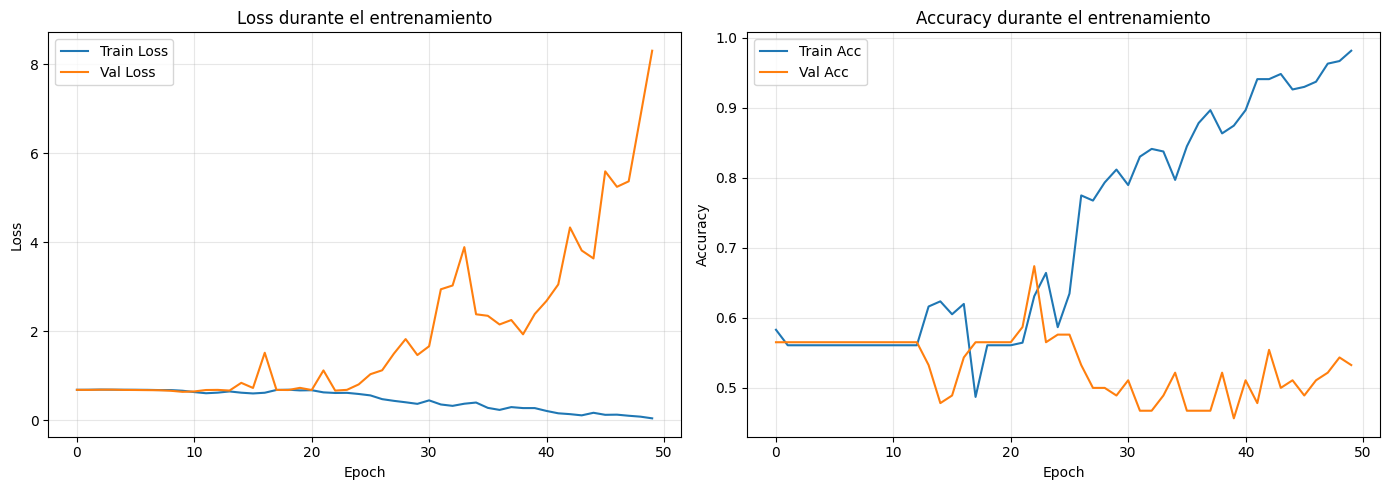

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss durante el entrenamiento')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy durante el entrenamiento')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluación en Test

In [ ]:
# Predicciones
y_pred_proba = wnc.predict(X_test)         # Probabilidades (N, 2)
y_pred = np.argmax(y_pred_proba, axis=1)    # Clase predicha
y_true = y_test_raw                          # Labels originales (no one-hot)

# Métricas
acc = accuracy_score(y_true, y_pred)
roc = roc_auc_score(y_true, y_pred_proba[:, 1])

print(f"{'='*50}")
print(f" RESULTADOS EN TEST (Fold {FOLD_IDX + 1})")
print(f"{'='*50}")
print(f"  Accuracy:  {acc:.4f}")
print(f"  ROC-AUC:   {roc:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=['Control', 'Patológicas']))

3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step
 RESULTADOS EN TEST (Fold 1)
  Accuracy:  0.5055
  ROC-AUC:   0.4238

              precision    recall  f1-score   support

     Control       0.42      0.35      0.38        40
 Patológicas       0.55      0.63      0.59        51

    accuracy                           0.51        91
   macro avg       0.49      0.49      0.49        91
weighted avg       0.50      0.51      0.50        91



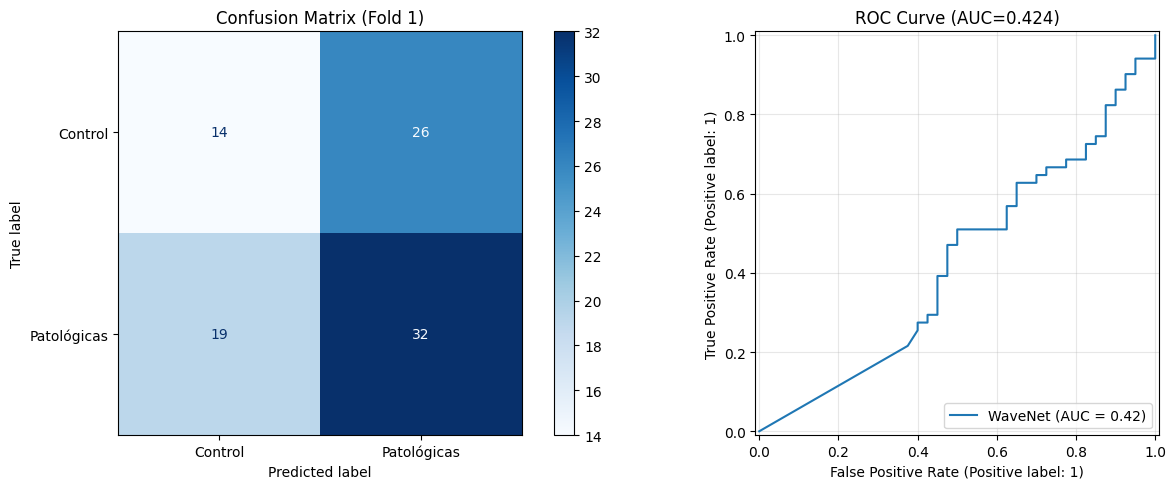

In [ ]:
# Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Control', 'Patológicas'])
disp.plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix (Fold {FOLD_IDX+1})')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_true, y_pred_proba[:, 1],
    name='WaveNet',
    ax=axes[1]
)
axes[1].set_title(f'ROC Curve (AUC={roc:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. (Opcional) K-Fold Completo

Ejecuta el entrenamiento y evaluación para todos los K folds y reporta métricas promedio.  
**⚠ Descomenta para ejecutar** (tarda bastante).

In [ ]:
# all_accs = []
# all_aucs = []
# 
# for k in range(K):
#     print(f"\n{'='*60}")
#     print(f" FOLD {k+1}/{K}")
#     print(f"{'='*60}")
#     
#     fd = folds[k]
#     Xtr, ytr_raw, Xv, yv_raw, Xte, yte_raw = load_fold_data(
#         fd, DATA_DIR, WAVENET_SR, TARGET_SAMPLES
#     )
#     
#     ytr = to_categorical(ytr_raw, NUM_CLASSES)
#     yv  = to_categorical(yv_raw,  NUM_CLASSES)
#     
#     # Crear modelo nuevo para cada fold
#     model_k = WaveNetClassifier(
#         input_shape    = (TARGET_SAMPLES,),
#         output_shape   = (NUM_CLASSES,),
#         kernel_size    = KERNEL_SIZE,
#         dilation_depth = DILATION_DEPTH,
#         n_filters      = N_FILTERS,
#         task           = 'classification'
#     )
#     
#     # Compilar y entrenar directamente (compatible Keras 3)
#     model_k.model.compile(
#         optimizer=OPTIMIZER,
#         loss=tf.keras.losses.CategoricalCrossentropy(),
#         metrics=['accuracy']
#     )
#     model_k.model.fit(Xtr, ytr, validation_data=(Xv, yv),
#                       epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True)
#     
#     yp_proba = model_k.predict(Xte)
#     yp = np.argmax(yp_proba, axis=1)
#     
#     acc_k = accuracy_score(yte_raw, yp)
#     auc_k = roc_auc_score(yte_raw, yp_proba[:, 1])
#     all_accs.append(acc_k)
#     all_aucs.append(auc_k)
#     
#     print(f"  → Fold {k+1} Acc={acc_k:.4f}  AUC={auc_k:.4f}")
# 
# print(f"\n{'='*60}")
# print(f" RESULTADOS K-FOLD PROMEDIO")
# print(f"{'='*60}")
# print(f"  Accuracy: {np.mean(all_accs):.4f} ± {np.std(all_accs):.4f}")
# print(f"  ROC-AUC:  {np.mean(all_aucs):.4f} ± {np.std(all_aucs):.4f}")